## NERUALNETWORK CLASSIFICATION

In [329]:
import torch
from torch.nn import Module
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [330]:
n_samples= 1000

#create cirkles

X, y = make_circles(n_samples, noise= 0.03, random_state=42)

len(X), len(y)

(1000, 1000)

In [331]:
print('first 5 samples of X\n', X[:5])
print('first 5 samples of y\n', y[:5])

first 5 samples of X
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
first 5 samples of y
 [1 1 1 1 0]


In [332]:
# MAKE A DATAFRAME

import pandas as pd

circles = pd.DataFrame({'X1': X[:, 0], 
                        'X2': X[:, 1],
                        'label': y})

circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


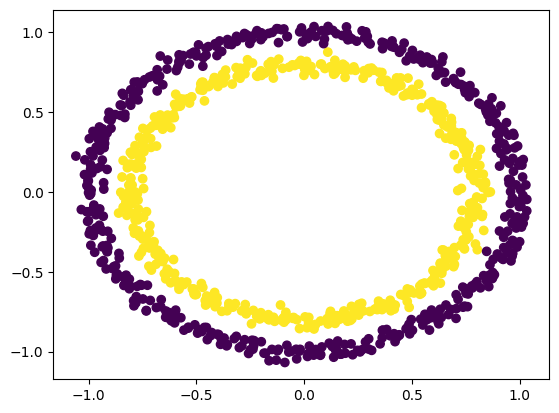

In [333]:
plt.scatter(x= X[:, 0], y= X[:, 1], c=y)
plt.show()

CHECK INPUT AND OUTPUT SHAPES

In [334]:
X.shape, y.shape

((1000, 2), (1000,))

## 1. TURN DATA INTO TENSORS AND TRAIN SPLITS

In [335]:
type(X)

numpy.ndarray

In [336]:
try:
    X= torch.from_numpy(X).type(torch.float)


except Exception as e:
    print(f'already made tensor: ({type(X)}) error: {e}')

try:
   
    y= torch.from_numpy(y).type(torch.float)

except Exception as e:
    print(f'already made tensor: ({type(y)}) error: {e}')


In [337]:
X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

print(len(X_train), len(y_train), len(X_test), len(y_test))

800 800 200 200


## 2. BUILDING MODEL

1. setup device
2. construct model
3. loss fn andoptimizer
4. train test loop


In [338]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [339]:
X_train.to(device)

X_train.device

device(type='cpu')

In [340]:
from typing import Any


class ClassificationModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1= torch.nn.Linear(in_features=2, out_features=7, device=device)
        self.layer2= torch.nn.Linear(in_features=7, out_features=5, device=device)
        self.layer3= torch.nn.Linear(in_features=5, out_features=1, device=device)

    def forward(self, x) -> torch.Tensor:
        #return self.layer3(self.layer2(self.layer1(x))) 
        x= self.layer1(x)
        x= self.layer2(x)
        x= self.layer3(x)

        return x
    


In [341]:
model= ClassificationModel().to(device)
next(model.parameters()).device
model.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958]])),
             ('layer1.bias',
              tensor([ 0.3410, -0.0998,  0.5451,  0.1045, -0.3301,  0.1802, -0.3258])),
             ('layer2.weight',
              tensor([[-0.0443, -0.1535,  0.2507, -0.2984, -0.1742, -0.1067, -0.2273],
                      [ 0.0357, -0.3733,  0.3413, -0.3211,  0.2918,  0.0629, -0.1227],
                      [ 0.2336,  0.0589,  0.3054,  0.0413, -0.1192,  0.1016, -0.1025],
                      [ 0.1591,  0.3375,  0.2185, -0.1652,  0.2182,  0.0676,  0.1919],
                      [-0.2304, -0.3742, -0.1460, -0.2899,  0.3101,  0.1089,  0.1566]])),
             ('layer2.bias',
              tensor([ 0.1195, -0.0066,  0.2958, -0.2685,

NN.Sequential model??

In [342]:

model_sequential= torch.nn.Sequential(
    torch.nn.Linear(in_features=2, out_features=7),
    torch.nn.Linear(in_features=7, out_features= 5),
    torch.nn.Linear(in_features=5, out_features=1)
).to(device)

model_sequential.state_dict() 

OrderedDict([('0.weight',
              tensor([[-0.4191, -0.4217],
                      [-0.4217,  0.6360],
                      [ 0.2356,  0.6804],
                      [-0.5836, -0.7014],
                      [-0.5532, -0.4757],
                      [ 0.2864,  0.2532],
                      [ 0.5876, -0.3652]])),
             ('0.bias',
              tensor([-0.4820,  0.3752, -0.2858,  0.4292, -0.1678,  0.4045, -0.5494])),
             ('1.weight',
              tensor([[-0.1907,  0.1152,  0.0799, -0.0964,  0.2253,  0.2569, -0.2741],
                      [-0.2018,  0.3461, -0.1275, -0.1340, -0.3657, -0.2164,  0.0944],
                      [-0.0499, -0.2744,  0.0089, -0.2582, -0.3207, -0.2081, -0.3308],
                      [-0.2407,  0.3778,  0.0714,  0.1165, -0.3525, -0.2482, -0.1258],
                      [ 0.0591, -0.3326, -0.1629, -0.2263,  0.0010, -0.1406, -0.0262]])),
             ('1.bias', tensor([-0.2561, -0.2594, -0.2205, -0.1294, -0.2983])),
             ('2.weig

MAKE PREDICTOINS

In [343]:
with torch.inference_mode():
    model.eval()
    model_sequential.eval()
    
    untrained_preds= model_sequential(X_test.to(device))
    untrained_preds1= model(X_test.to(device))

print(f'first 10 preds: {untrained_preds[:10]}')
print(f'first 10 labels: {y_test[:10]}')

first 10 preds: tensor([[0.5577],
        [0.1608],
        [0.1479],
        [0.3242],
        [0.7193],
        [0.6254],
        [0.3859],
        [0.7279],
        [0.8019],
        [0.1949]])
first 10 labels: tensor([1., 0., 0., 0., 1., 1., 1., 1., 0., 0.])


LOSS FN/ optimizer

In [344]:
loss_fn= torch.nn.BCEWithLogitsLoss() # innehåller sigmoid activation function? 


optim= torch.optim.SGD(params=model_sequential.parameters(), lr= 0.001)

In [345]:
#calculate accuracy

def accaracy_fn(y_true, y_preds):
    correct= torch.eq(y_true, y_preds).sum().item()
    acc= (correct/ len(y_true + y_preds)) * 100

    return acc

Logits are raw outputs of our model and we the output of the model to be in the same format as the "true data"


USE SIGMOID

it tranforms the logits so we then can round then. The outputs will be L > 0.5 = 1 and revurse 0

## SIGMOID  
ANVÄNDS FÖR ATT GÖRA NÅGON BERÄKNING PÅ LOGITS FRÅN RESULTAT MED BINÄR CLASSIFICERING OCH 
## SOFTMAX 
ANVÄNDS FÖR MULTICLASS CLASSIFICERING

In [346]:
y_test

tensor([1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0.,
        1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0.,
        0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 0.,
        0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0.,
        1., 1., 1., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1., 0., 1.,
        0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0.,
        1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1.,
        1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1.,
        1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0.,
        1., 1.])

In [347]:
model.eval()

with torch.inference_mode():
    
    y_logits= model(X_test) #eval
    y_sigmoid= torch.sigmoid(y_logits) #sigmoid skit
    y_rounded= torch.round(y_sigmoid)# rundat till 1 eller 0
    y_rounded= y_rounded.squeeze() # bort med en dimension

    y_preds= torch.eq(y_rounded, y_test) # jämnför predictions med actual 


count=0
for a in y_preds:
    
    if a == True:
        count+=1

count


100

TRAIN/ TESTLOOP

In [348]:
torch.manual_seed(42)
EPOCHS= 1200


for epoch in range(EPOCHS):
    model_sequential.train()
    
    #1. foward pass
    y_logits= model_sequential(X_train).squeeze()
    y_preds= torch.round(torch.sigmoid(y_logits))
    

    #2. calculate the loss
    loss= loss_fn(y_logits, y_train)  # våran BCEwithlogitsloss vill ha ren logits annars får vi göra rounds/sigmoid grejen
    acc= accaracy_fn(y_train, y_preds)
    

    #3. optimizer zero grad
    optim.zero_grad()

    #4. Loss backward
    loss.backward()

    #5. Optimizer step
    optim.step()

    model_sequential.eval()

    with torch.inference_mode():
        #pass
        test_logits= model_sequential(X_test).squeeze()
        test_pred= torch.round(torch.sigmoid(test_logits))

        #loss
        test_loss= loss_fn(test_logits, y_test)
        test_acc= accaracy_fn(y_test, test_pred)

        if epoch % 100 == 0:
            print(f'EPOCH: {epoch} | Loss: {loss:.5f} | accuracy: {acc:.5f}')
            print(f'EPOCH: {epoch} | test Loss: {test_loss:.5f} | test accuracy: {test_acc:.5f} %\n')


EPOCH: 0 | Loss: 0.72642 | accuracy: 50.00000
EPOCH: 0 | test Loss: 0.72081 | test accuracy: 50.00000 %

EPOCH: 100 | Loss: 0.72303 | accuracy: 50.00000
EPOCH: 100 | test Loss: 0.71757 | test accuracy: 50.00000 %

EPOCH: 200 | Loss: 0.72004 | accuracy: 50.00000
EPOCH: 200 | test Loss: 0.71471 | test accuracy: 50.00000 %

EPOCH: 300 | Loss: 0.71740 | accuracy: 50.00000
EPOCH: 300 | test Loss: 0.71220 | test accuracy: 50.00000 %

EPOCH: 400 | Loss: 0.71506 | accuracy: 50.00000
EPOCH: 400 | test Loss: 0.70998 | test accuracy: 50.00000 %

EPOCH: 500 | Loss: 0.71299 | accuracy: 50.00000
EPOCH: 500 | test Loss: 0.70803 | test accuracy: 50.00000 %

EPOCH: 600 | Loss: 0.71115 | accuracy: 50.00000
EPOCH: 600 | test Loss: 0.70629 | test accuracy: 50.00000 %

EPOCH: 700 | Loss: 0.70951 | accuracy: 50.00000
EPOCH: 700 | test Loss: 0.70476 | test accuracy: 50.50000 %

EPOCH: 800 | Loss: 0.70805 | accuracy: 51.50000
EPOCH: 800 | test Loss: 0.70340 | test accuracy: 51.00000 %

EPOCH: 900 | Loss: 0.70

## Ways to improve models

* add layers 
* add more hidden units/ nodes?
* changing activation function- sigmoid for example
* changing learning rate
* changing loss fn

In [349]:



class ImprovedModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layer1= torch.nn.Linear(in_features=2, out_features=10)
        self.layer2= torch.nn.Linear(in_features=10, out_features=16)
        self.layer3= torch.nn.Linear(in_features=16, out_features=10)
        self.layer4= torch.nn.Linear(in_features=10, out_features=1)

    def forward(self, x) -> torch.Tensor:
        
        # x= self.layer1(x)
        # x= self.layer2(x)
        # x= self.layer3(x)
        # x= self.layer4(x)


        return self.layer4(self.layer3(self.layer2(self.layer1(x))))
    
model1= ImprovedModel()

optimizer= torch.optim.Adam(params=model1.parameters(), lr=0.01)

In [350]:
EPOCHS = 1000


for epoch in range(EPOCHS):

    model1.train()

    logits= model1(X_train).squeeze()
    sigm= torch.sigmoid(logits)
    y_preds=torch.round(sigm)

    train_loss= loss_fn(logits, y_train)
    train_acc= accaracy_fn(y_train, y_preds)

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    model1.eval()

    with torch.inference_mode():

        test_logits= model1(X_test).squeeze()
        sigm= torch.sigmoid(test_logits)
        test_pred= torch.round(sigm)

        loss= loss_fn(test_logits, y_test)
        acc= accaracy_fn(y_test, test_pred)

    if epoch % 100 == 0:
        print(f'training: epoch {epoch} loss: {train_loss:.3f} acc: {train_acc}')
        print(f'test: epoch {epoch} loss: {loss:.3f} acc: {acc}\n')

training: epoch 0 loss: 0.720 acc: 50.0
test: epoch 0 loss: 0.706 acc: 50.0



training: epoch 100 loss: 0.693 acc: 50.5
test: epoch 100 loss: 0.694 acc: 49.0

training: epoch 200 loss: 0.693 acc: 50.125
test: epoch 200 loss: 0.694 acc: 48.5

training: epoch 300 loss: 0.693 acc: 50.125
test: epoch 300 loss: 0.694 acc: 48.5

training: epoch 400 loss: 0.693 acc: 50.125
test: epoch 400 loss: 0.694 acc: 48.5

training: epoch 500 loss: 0.693 acc: 50.125
test: epoch 500 loss: 0.694 acc: 48.5

training: epoch 600 loss: 0.693 acc: 50.125
test: epoch 600 loss: 0.694 acc: 48.5

training: epoch 700 loss: 0.693 acc: 50.125
test: epoch 700 loss: 0.694 acc: 48.5

training: epoch 800 loss: 0.693 acc: 50.125
test: epoch 800 loss: 0.694 acc: 48.5

training: epoch 900 loss: 0.693 acc: 50.125
test: epoch 900 loss: 0.694 acc: 48.5



## CREATING NON LINEAR MODELS

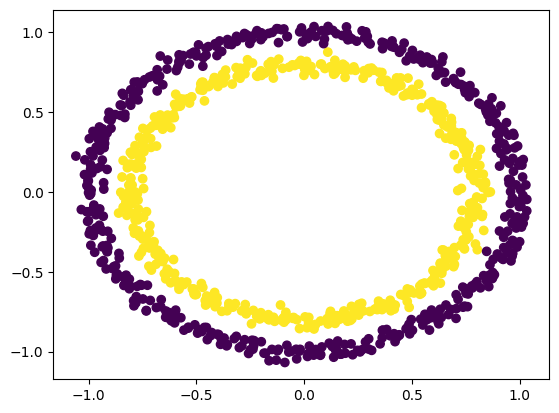

In [351]:
# DATA

n_samples= 1000

X, y = make_circles(n_samples=n_samples, noise= 0.03, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y )

In [352]:
X= torch.Tensor(X)
y= torch.Tensor(y)

X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=42, stratify=y, test_size=0.2) 


class CircleModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1= torch.nn.Linear(in_features= 2, out_features=10)
        self.layer2= torch.nn.Linear(in_features= 10, out_features=10)
        self.layer3= torch.nn.Linear(in_features= 10, out_features=1)
        self.relu= torch.nn.ReLU() # non linear activation function

    def forward(self, x):

        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))
    
circle_model= CircleModel()
circle_model

CircleModel(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [353]:
loss_fn= torch.nn.BCEWithLogitsLoss()
optimizer= torch.optim.SGD(circle_model.parameters(), lr= 0.1)

In [354]:
EPOCHS = 10000


for epoch in range(EPOCHS):

    circle_model.train()

    logits= circle_model(X_train).squeeze()
    sigm= torch.sigmoid(logits)
    y_preds=torch.round(sigm)

    train_loss= loss_fn(logits, y_train)
    train_acc= accaracy_fn(y_train, y_preds)

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    circle_model.eval()

    with torch.inference_mode():

        test_logits= circle_model(X_test).squeeze()
        sigm= torch.sigmoid(test_logits)
        test_pred= torch.round(sigm)

        loss= loss_fn(test_logits, y_test)
        acc= accaracy_fn(y_test, test_pred)

    if epoch % 1000 == 0:
        print(f'training: epoch {epoch} loss: {train_loss:.3f} acc: {train_acc}')
        print(f'test: epoch {epoch} loss: {loss:.3f} acc: {acc}\n')

training: epoch 0 loss: 0.697 acc: 50.0
test: epoch 0 loss: 0.696 acc: 50.0

training: epoch 1000 loss: 0.636 acc: 77.375
test: epoch 1000 loss: 0.639 acc: 74.0

training: epoch 2000 loss: 0.046 acc: 100.0
test: epoch 2000 loss: 0.039 acc: 100.0

training: epoch 3000 loss: 0.014 acc: 100.0
test: epoch 3000 loss: 0.011 acc: 100.0

training: epoch 4000 loss: 0.008 acc: 100.0
test: epoch 4000 loss: 0.007 acc: 100.0

training: epoch 5000 loss: 0.005 acc: 100.0
test: epoch 5000 loss: 0.005 acc: 100.0

training: epoch 6000 loss: 0.004 acc: 100.0
test: epoch 6000 loss: 0.004 acc: 100.0

training: epoch 7000 loss: 0.003 acc: 100.0
test: epoch 7000 loss: 0.003 acc: 100.0

training: epoch 8000 loss: 0.003 acc: 100.0
test: epoch 8000 loss: 0.003 acc: 100.0

training: epoch 9000 loss: 0.002 acc: 100.0
test: epoch 9000 loss: 0.003 acc: 100.0



## MULTICLASS CLASSIFICATION

In [355]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


In [356]:
num_classes= 6
num_features= 2
SEED=42

X_blob, y_blob= make_blobs(n_samples=1000, n_features=num_features, random_state=SEED, centers=num_classes, cluster_std=1.5) #type: ignore


X_blob= torch.tensor(X_blob).type(torch.float32)
y_blob= torch.tensor(y_blob).type(torch.long)

print(X_blob.dtype)
print(y_blob.dtype)

torch.float32
torch.int64


In [357]:
X_blob_train, X_blob_test, y_blob_train, y_blob_test=train_test_split(X_blob, y_blob, test_size=0.2, random_state=SEED)

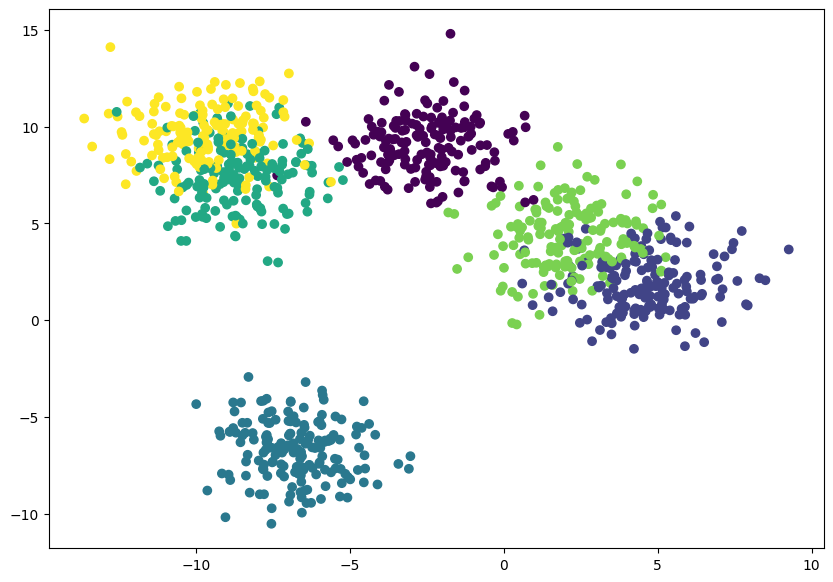

In [358]:
plt.figure(figsize=(10, 7))

plt.scatter(X_blob[:, 0], X_blob[:, 1], c= y_blob)

In [359]:
class multiclassModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=12):
        """ 
        
        """
        
        
        super().__init__()

        self.linear_layer_stack= nn. Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

        # self.layer1= nn.Linear(in_features=2, out_features=10)
        # self.layer2= nn.Linear(in_features=10, out_features=16)
        # self.layer3= nn.Linear(in_features=16, out_features=6)
        # self.relu= nn.ReLU()

    def forward(self, x):
        
        #return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))
        return self.linear_layer_stack(x)
    
multiclassmodel= multiclassModel(input_features=2, output_features=6)

loss_fn= nn.CrossEntropyLoss() #multiklass loss fn 
optimizer= torch.optim.SGD(multiclassmodel.parameters(), lr= 0.01) #samma som binär klassificering 

multiclassmodel

multiclassModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=12, bias=True)
    (3): ReLU()
    (4): Linear(in_features=12, out_features=6, bias=True)
  )
)

## Logits -> predprob ( `torch.softmax` ) -> pred labes (`argmax`)

In [360]:
multiclassmodel.eval()

with torch.inference_mode():
    logits= multiclassmodel(X_blob_test)


y_blob_test

tensor([1, 1, 2, 3, 0, 4, 5, 1, 2, 1, 0, 3, 1, 3, 2, 4, 5, 0, 4, 2, 1, 5, 4, 1,
        0, 4, 5, 1, 2, 3, 3, 3, 4, 4, 3, 1, 1, 5, 1, 0, 4, 0, 5, 1, 5, 0, 5, 2,
        3, 2, 1, 3, 5, 4, 2, 1, 5, 5, 3, 0, 5, 0, 4, 1, 2, 5, 2, 1, 3, 5, 2, 4,
        3, 3, 4, 0, 3, 0, 3, 0, 2, 3, 5, 3, 2, 0, 2, 0, 0, 2, 2, 2, 0, 3, 4, 4,
        3, 0, 5, 2, 5, 4, 0, 4, 0, 0, 0, 4, 0, 3, 2, 3, 1, 4, 0, 5, 5, 3, 1, 1,
        3, 1, 5, 2, 0, 5, 5, 3, 4, 5, 3, 5, 4, 1, 3, 0, 3, 3, 1, 1, 4, 3, 2, 3,
        3, 1, 5, 3, 1, 1, 3, 3, 0, 5, 2, 4, 3, 3, 1, 0, 0, 4, 3, 5, 5, 0, 0, 2,
        5, 3, 1, 5, 0, 0, 3, 5, 5, 0, 5, 5, 1, 4, 2, 3, 3, 5, 0, 3, 1, 3, 3, 3,
        2, 1, 5, 1, 0, 5, 5, 2])

In [361]:
#convert test logits to probabilities

y_preds_probs= torch.softmax(logits, dim=1)

y_preds_probs

tensor([[0.1763, 0.1867, 0.1139, 0.1312, 0.1905, 0.2014],
        [0.1781, 0.1859, 0.1129, 0.1309, 0.1906, 0.2016],
        [0.1215, 0.2197, 0.1849, 0.1204, 0.1754, 0.1782],
        ...,
        [0.1758, 0.2058, 0.1763, 0.0901, 0.1859, 0.1662],
        [0.1775, 0.1933, 0.1841, 0.0876, 0.1943, 0.1632],
        [0.1171, 0.2245, 0.1846, 0.1218, 0.1732, 0.1789]])

In [362]:
#convert models prediction probs to prediction labels

y_preds= torch.argmax(y_preds_probs, dim=1)
y_preds

tensor([5, 5, 1, 1, 2, 4, 1, 0, 1, 0, 2, 1, 4, 1, 2, 5, 1, 2, 0, 1, 0, 4, 5, 0,
        2, 5, 1, 1, 1, 1, 1, 1, 0, 5, 2, 0, 5, 1, 0, 2, 5, 2, 1, 4, 2, 2, 2, 2,
        2, 1, 4, 1, 1, 5, 1, 4, 1, 1, 1, 2, 4, 2, 5, 1, 1, 1, 1, 0, 1, 2, 1, 5,
        2, 2, 5, 2, 1, 2, 1, 2, 1, 1, 1, 4, 1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 5, 5,
        4, 2, 4, 2, 4, 4, 2, 5, 2, 2, 2, 5, 2, 1, 1, 1, 4, 2, 2, 4, 2, 4, 1, 5,
        1, 0, 4, 1, 2, 1, 4, 4, 5, 1, 1, 1, 5, 5, 1, 5, 4, 2, 5, 0, 5, 4, 1, 1,
        1, 0, 1, 2, 0, 5, 1, 1, 2, 1, 1, 5, 1, 1, 5, 2, 2, 5, 1, 4, 2, 2, 2, 1,
        1, 2, 5, 4, 2, 2, 1, 4, 2, 2, 1, 2, 1, 4, 1, 1, 4, 1, 2, 1, 5, 1, 4, 1,
        1, 0, 2, 0, 2, 1, 4, 1])

## Training and testing loop

In [363]:
torch.manual_seed(42)

EPOCHS=5000

for epoch in range(EPOCHS):

    multiclassmodel.train()

    logits= multiclassmodel(X_blob_train)
    y_train_prob= torch.softmax(logits, dim=1)
    y_preds= torch.argmax(y_train_prob, dim=1)

    
    loss= loss_fn(logits, y_blob_train)
    acc= accaracy_fn(y_blob_train, y_preds)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    #testing

    multiclassmodel.eval()

    with torch.inference_mode():

        test_logits= multiclassmodel(X_blob_test)
        y_test_prob= torch.softmax(test_logits, dim=1)
        y_test_probs= torch.argmax(y_test_prob, dim=1)

        test_loss= loss_fn(test_logits, y_blob_test)
        test_acc=  accaracy_fn(y_blob_test, y_test_probs)

    if epoch % 1000 == 0:
        print(f'epoch: {epoch} | train loss: {loss:.5f} | train acc: {acc:.5f}')
        print(f'epoch: {epoch} | test loss: {test_loss:.5f} | test acc: {test_acc:.5f}\n')
        

epoch: 0 | train loss: 1.86345 | train acc: 7.12500
epoch: 0 | test loss: 1.90028 | test acc: 7.00000

epoch: 1000 | train loss: 0.36278 | train acc: 83.75000
epoch: 1000 | test loss: 0.41898 | test acc: 80.00000

epoch: 2000 | train loss: 0.33903 | train acc: 84.87500
epoch: 2000 | test loss: 0.38733 | test acc: 81.50000

epoch: 3000 | train loss: 0.32505 | train acc: 85.37500
epoch: 3000 | test loss: 0.36881 | test acc: 82.50000

epoch: 4000 | train loss: 0.31287 | train acc: 86.37500
epoch: 4000 | test loss: 0.35282 | test acc: 84.00000

